# hp-Convergence Study — pyCAFE only

**Problema:** cavità rettangolare 2D, 1 m × 0.5 m, aria (c₀ = 343 m/s, ρ = 1.204 kg/m³).  
**Condizioni al contorno:** pareti rigide su tutto il perimetro (Neumann: ∂p/∂n = 0).  
**Problema agli autovalori:** K φ = λ M φ, con λ = ω² = (2πf)².

## Soluzione analitica

Per una cavità rettangolare con pareti rigide, le frequenze proprie sono:

$$f_{m,n} = \frac{c_0}{2}\sqrt{\left(\frac{m}{L_x}\right)^2 + \left(\frac{n}{L_y}\right)^2}, \quad m,n = 0,1,2,\ldots \quad (m+n > 0)$$

---

## Piano dello studio

| Studio | Variabile | Fissato |
|---|---|---|
| **h-convergenza** | dimensione elemento h (numero elementi) | ordine p |
| **p-convergenza** | ordine polinomiale p (CQUAD4 vs CQUAD8) | mesh fissa |

**Tassi di convergenza attesi** per problemi agli autovalori con soluzione regolare:

| Elemento | Ordine p | Tasso su frequenza | Tasso su errore relativo % |
|---|---|---|---|
| CQUAD4 | 1 | O(h²) | slope ≈ 2 nel grafico log-log |
| CQUAD8 | 2 | O(h⁴) | slope ≈ 4 nel grafico log-log |

> **Nota:** per il problema agli autovalori, l'errore sull'autovalore λ = ω² è O(h^{2p}),  
> quindi l'errore sulla frequenza f = √λ/(2π) è O(h^p) per p=1 → slope 2 su errore%, per p=2 → slope 4.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import time
import os
import sys
import tempfile
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))

# ── Parametri del problema ────────────────────────────────────────────────────
Lx  = 1.0    # larghezza cavità [m]
Ly  = 0.5    # altezza cavità [m]
c0  = 343.0  # velocità del suono aria [m/s]
rho = 1.204  # densità aria [kg/m³]
NUM_MODES = 6  # numero di modi da calcolare

# ── Frequenze analitiche di riferimento ──────────────────────────────────────
# Escludiamo (0,0): modo triviale a f=0 (pressione uniforme, λ=0)
# Teniamo solo frequenze UNICHE (le degeneri come f(2,0)=f(0,1) compaiono una sola volta)
def analytical_modes(Lx, Ly, c0, n_modes=10):
    freqs = []
    for m in range(20):
        for n in range(20):
            if m == 0 and n == 0:
                continue
            f = (c0 / 2) * np.sqrt((m / Lx)**2 + (n / Ly)**2)
            freqs.append((round(f, 6), m, n))
    freqs.sort()
    seen, out = set(), []
    for f, m, n in freqs:
        if f not in seen:
            seen.add(f)
            out.append((f, m, n))
        if len(out) == n_modes:
            break
    return out

modes_ref = analytical_modes(Lx, Ly, c0, NUM_MODES)
f_ref     = np.array([f for f, m, n in modes_ref])

print('=== Frequenze proprie analitiche di riferimento ===')
print(f"{'#':>3}  {'modo (m,n)':>12}  {'f analitica [Hz]':>18}")
print('-' * 38)
for i, (f, m, n) in enumerate(modes_ref):
    print(f"  {i+1:>1}  ({m},{n}){' ':>8}  {f:>18.4f}")

# ── Metriche di errore ────────────────────────────────────────────────────────
def match_errors(freqs_fem, f_ref_arr):
    """Greedy closest-match: per ogni frequenza analitica trova la FEM più vicina.
    Robusto rispetto ai modi degeneri e al riordino del solver.
    Ritorna errore relativo medio [%]."""
    available = list(freqs_fem)
    errors = []
    for f_an in f_ref_arr:
        if not available:
            break
        diffs = [abs(f - f_an) / f_an for f in available]
        best = int(np.argmin(diffs))
        errors.append(diffs[best])
        available.pop(best)
    return float(np.mean(errors)) * 100.0 if errors else 100.0

print('\nSetup completato.')

=== Frequenze proprie analitiche di riferimento ===
  #    modo (m,n)    f analitica [Hz]
--------------------------------------
  1  (1,0)                    171.5000
  2  (0,1)                    343.0000
  3  (1,1)                    383.4857
  4  (2,1)                    485.0753
  5  (3,0)                    514.5000
  6  (3,1)                    618.3520

Setup completato.


---
## 1 — Generazione della mesh con Gmsh

Usiamo Gmsh per generare mesh **strutturate** di quadrilateri (transfinite mesh):  
- **Nx × Ny** celle per lato → ogni cella diventa un elemento
- `order=1` → **CQUAD4** (4 nodi, bilineare Q1)
- `order=2` → **CQUAD8** (8 nodi, serendipity Q2, senza nodo centrale)

Scegliamo sempre **Ny = Nx // 2** per mantenere elementi circa quadrati  
(cavità 1 m × 0.5 m → rapporto di aspetto 2:1).

In [2]:
import gmsh

def make_mesh(Nx, Ny, order, msh_path):
    """
    Genera una mesh rettangolare strutturata di quadrilateri.

    Parametri
    ---------
    Nx, Ny   : numero di celle nelle direzioni x e y
    order    : 1 -> CQUAD4 (Q1), 2 -> CQUAD8 (Q2 serendipity)
    msh_path : percorso file .msh di output
    """
    if gmsh.isInitialized():
        gmsh.finalize()
    gmsh.initialize()
    gmsh.model.add('rect')
    gmsh.option.setNumber('General.Verbosity', 0)

    # Geometria: 4 punti, 4 linee, 1 superficie
    p1 = gmsh.model.geo.addPoint(0,   0,   0)
    p2 = gmsh.model.geo.addPoint(Lx,  0,   0)
    p3 = gmsh.model.geo.addPoint(Lx,  Ly,  0)
    p4 = gmsh.model.geo.addPoint(0,   Ly,  0)
    l1 = gmsh.model.geo.addLine(p1, p2)  # bottom
    l2 = gmsh.model.geo.addLine(p2, p3)  # right
    l3 = gmsh.model.geo.addLine(p3, p4)  # top
    l4 = gmsh.model.geo.addLine(p4, p1)  # left
    cl   = gmsh.model.geo.addCurveLoop([l1, l2, l3, l4])
    surf = gmsh.model.geo.addPlaneSurface([cl])

    # Gruppi fisici (necessari per pycafe)
    gmsh.model.addPhysicalGroup(1, [l1], name='bottom')
    gmsh.model.addPhysicalGroup(1, [l2], name='right')
    gmsh.model.addPhysicalGroup(1, [l3], name='top')
    gmsh.model.addPhysicalGroup(1, [l4], name='left')
    gmsh.model.addPhysicalGroup(2, [surf], name='domain')
    gmsh.model.geo.synchronize()

    # Mesh strutturata transfinite (griglia regolare)
    gmsh.model.mesh.setTransfiniteCurve(l1, Nx + 1)
    gmsh.model.mesh.setTransfiniteCurve(l3, Nx + 1)
    gmsh.model.mesh.setTransfiniteCurve(l2, Ny + 1)
    gmsh.model.mesh.setTransfiniteCurve(l4, Ny + 1)
    gmsh.model.mesh.setTransfiniteSurface(surf)
    gmsh.model.mesh.recombine()  # triangoli -> quadrilateri

    # Ordine degli elementi
    gmsh.option.setNumber('Mesh.ElementOrder', order)
    gmsh.option.setNumber('Mesh.RecombineAll', 1)
    if order == 2:
        # Serendipity: 8 nodi, senza nodo centrale (flag incompleto)
        gmsh.option.setNumber('Mesh.SecondOrderIncomplete', 1)

    gmsh.model.mesh.generate(2)
    gmsh.write(str(msh_path))
    gmsh.finalize()

# Cartella temporanea per i file mesh
tmpdir = tempfile.mkdtemp()
print(f'Mesh salvate in: {tmpdir}')
print('Generatore mesh pronto.')

Mesh salvate in: /var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6
Generatore mesh pronto.


---
## 2 — Partenza: mesh molto grossolana (Nx = 2)

Cominciamo con soli **2 × 1 = 2 elementi** per vedere quanto sono grandi gli errori  
con una discretizzazione estremamente rada.

MESH GROSSOLANA: Nx=2 (2x1 = 2 elementi)
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx002_p1.msh'...
Info    : 9 entities
Info    : 6 nodes
Info    : 8 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx002_p1.msh'
→ Line 2          | Dim: 1 | Order: 1 | Nodes/Elem: 2 | Count: 6
→ Quadrilateral 4 | Dim: 2 | Order: 1 | Nodes/Elem: 4 | Count: 2

Available boundary names in the mesh:
-------------------------------------
- bottom               | 1 nodes
- right                | 0 nodes
- top                  | 1 nodes
- left                 | 0 nodes


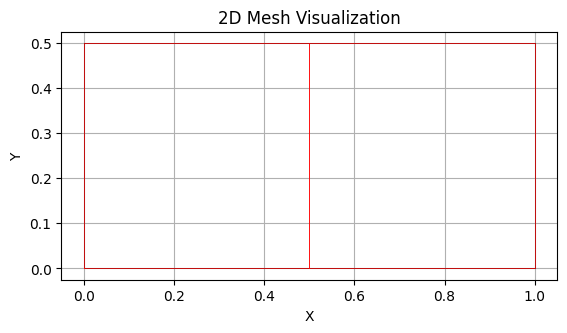

Detected acoustic element type: CQUAD4

--- CQUAD4 (p=1) ---
  DOF: 6,  errore medio: 8.6835%,  tempo: 0.009 s
    Modo (m,n)    f analitica [Hz]      f FEM [Hz]    errore %
  ----------------------------------------------------------
  (1,0)                    171.5000        189.1058     10.2658%
  (0,1)                    343.0000        378.2116     10.2658%
  (1,1)                    383.4857        378.2116      1.3753%
  (2,1)                    485.0753        422.8534     12.8272%
  (3,0)                    514.5000        422.8534     17.8127%
  (3,1)                    618.3520        422.8534     31.6161%
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx002_p2.msh'...
Info    : 9 entities
Info    : 13 nodes
Info    : 8 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx002_p2.msh'
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 6
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nod

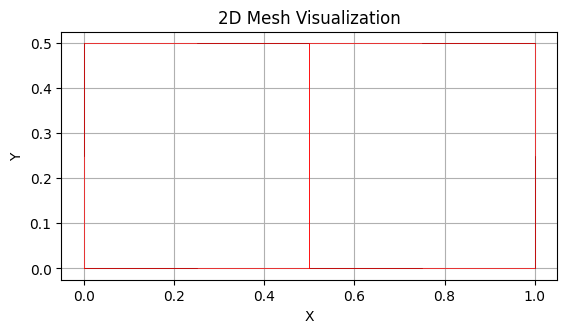

Detected acoustic element type: CQUAD8

--- CQUAD8 (p=2) ---
  DOF: 13,  errore medio: 6.9464%,  tempo: 0.015 s
    Modo (m,n)    f analitica [Hz]      f FEM [Hz]    errore %
  ----------------------------------------------------------
  (1,0)                    171.5000        172.1438      0.3754%
  (0,1)                    343.0000        378.2116     10.2658%
  (1,1)                    383.4857        378.2116      1.3753%
  (2,1)                    485.0753        534.8720     10.2658%
  (3,0)                    514.5000        534.8720      3.9596%
  (3,1)                    618.3520        619.3584      0.1627%


In [3]:
import pycafe
from pycafe.solver.solver_modale import solve_modal_acoustic_reduced

def run_pycafe(Nx, order, tmpdir, num_modes=NUM_MODES):
    """
    Esegue l'analisi modale con pyCAFE su una mesh Nx x (Nx//2).

    Ritorna
    -------
    h      : dimensione caratteristica elemento [m]
    n_dof  : numero di gradi di libertà
    freqs  : array frequenze proprie [Hz]
    err    : errore relativo medio % rispetto all'analitico
    t_wall : tempo totale di assemblaggio + risoluzione [s]
    """
    Ny = max(1, Nx // 2)
    msh = os.path.join(tmpdir, f'mesh_Nx{Nx:03d}_p{order}.msh')
    make_mesh(Nx, Ny, order, msh)

    fluid = pycafe.load_fluid('air')
    nodes, elements, boundaries = pycafe.load_mesh(msh)

    # Pareti rigide -> nessun nodo di Dirichlet
    bc = ([], [], 0.0, [], 0.0+0j, [], 0.0, None, 0.0)

    t0 = time.perf_counter()
    system = pycafe.prepare_acoustic_system(
        nodes=nodes, elements=elements, boundaries=boundaries,
        rho=fluid['rho'], c0=fluid['c0'], bc=bc, debug=False,
    )
    K_red = system['K_red']
    M_red = system['M_red']
    n_dof = K_red.shape[0]

    # Richiedere più modi per gestire il modo triviale e coppie degeneri
    n_req = min(num_modes * 3 + 4, n_dof - 1)
    freqs, modes = solve_modal_acoustic_reduced(K_red, M_red, num_modes=n_req)
    t_wall = time.perf_counter() - t0

    err = match_errors(freqs, f_ref)
    h   = Lx / Nx
    return h, n_dof, freqs, err, t_wall

# ── Mesh grossolana: 2x1 elementi ────────────────────────────────────────────
print('=' * 60)
print('MESH GROSSOLANA: Nx=2 (2x1 = 2 elementi)')
print('=' * 60)

for order, nome in [(1, 'CQUAD4 (p=1)'), (2, 'CQUAD8 (p=2)')]:
    h, n_dof, freqs, err, t = run_pycafe(2, order, tmpdir)
    print(f'\n--- {nome} ---')
    print(f'  DOF: {n_dof},  errore medio: {err:.4f}%,  tempo: {t:.3f} s')
    print(f"  {'Modo (m,n)':>12}  {'f analitica [Hz]':>18}  {'f FEM [Hz]':>14}  {'errore %':>10}")
    print('  ' + '-' * 58)
    for i, (f_an, m, n) in enumerate(modes_ref):
        # Trova la frequenza FEM più vicina
        idx = np.argmin(np.abs(freqs - f_an))
        f_fem = freqs[idx]
        e = abs(f_fem - f_an) / f_an * 100
        print(f"  ({m},{n}){' ':>8}  {f_an:>18.4f}  {f_fem:>14.4f}  {e:>10.4f}%")

---
## 3 — Studio di h-convergenza

Raffiniamo progressivamente la mesh (aumentando Nx) mantenendo **fisso l'ordine polinomiale**.  
Per ogni livello di raffinamento registriamo:
- `h` = dimensione caratteristica elemento = Lx / Nx
- `DOF` = gradi di libertà totali
- errore relativo medio % rispetto all'analitico
- tempo di assemblaggio + risoluzione

Eseguiamo per **CQUAD4** (p=1) e **CQUAD8** (p=2).

Avvio studio h-convergenza...
  Nx   Ny     h [m]    DOF Q4     err% Q4    t Q4 [s]    DOF Q8     err% Q8    t Q8 [s]
----------------------------------------------------------------------------------------
→ Line 2          | Dim: 1 | Order: 1 | Nodes/Elem: 2 | Count: 6
→ Quadrilateral 4 | Dim: 2 | Order: 1 | Nodes/Elem: 4 | Count: 2

Available boundary names in the mesh:
-------------------------------------
- bottom               | 1 nodes
- right                | 0 nodes
- top                  | 1 nodes
- left                 | 0 nodes
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx002_p1.msh'...
Info    : 9 entities
Info    : 6 nodes
Info    : 8 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx002_p1.msh'


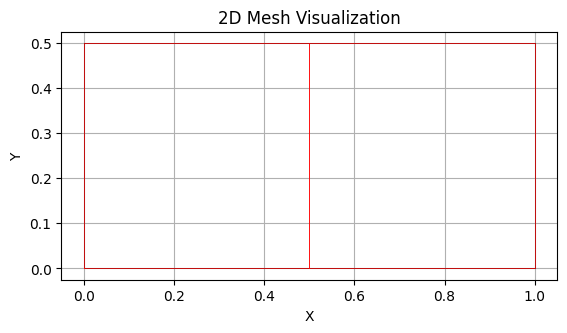

Detected acoustic element type: CQUAD4
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx002_p2.msh'...
Info    : 9 entities
Info    : 13 nodes
Info    : 8 elements
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 6
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx002_p2.msh'
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nodes/Elem: 8 | Count: 2

Available boundary names in the mesh:
-------------------------------------
- bottom               | 3 nodes
- right                | 1 nodes
- top                  | 3 nodes
- left                 | 1 nodes


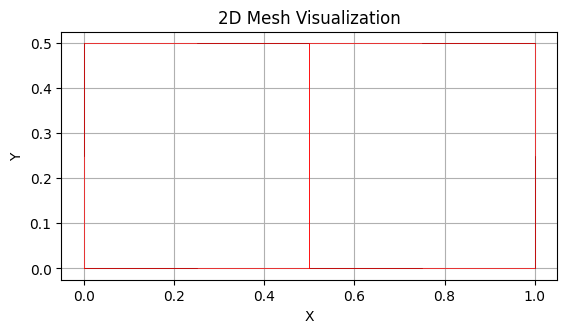

Detected acoustic element type: CQUAD8
   2    1    0.5000         6     8.68352%       0.001        13     6.94638%       0.002
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx004_p1.msh'...
Info    : 9 entities
Info    : 15 nodes
Info    : 20 elements
→ Line 2          | Dim: 1 | Order: 1 | Nodes/Elem: 2 | Count: 12
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx004_p1.msh'
→ Quadrilateral 4 | Dim: 2 | Order: 1 | Nodes/Elem: 4 | Count: 8

Available boundary names in the mesh:
-------------------------------------
- bottom               | 3 nodes
- right                | 1 nodes
- top                  | 3 nodes
- left                 | 1 nodes


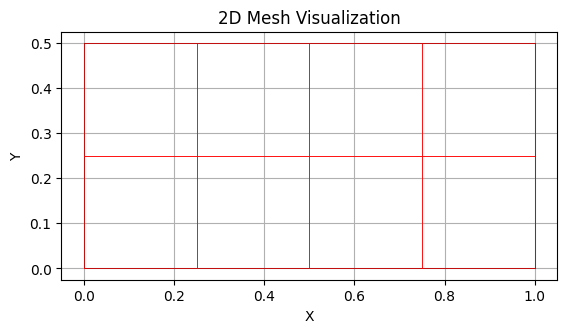

Detected acoustic element type: CQUAD4
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx004_p2.msh'...
Info    : 9 entities
Info    : 37 nodes
Info    : 20 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx004_p2.msh'
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 12
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nodes/Elem: 8 | Count: 8

Available boundary names in the mesh:
-------------------------------------
- bottom               | 7 nodes
- right                | 3 nodes
- top                  | 7 nodes
- left                 | 3 nodes


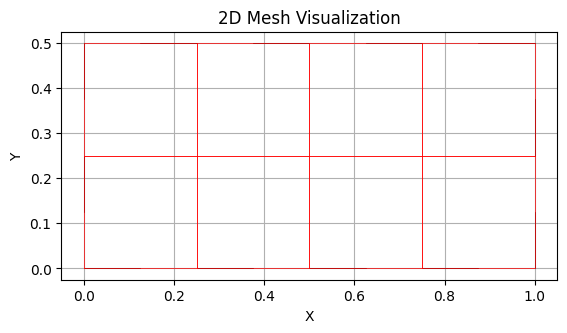

Detected acoustic element type: CQUAD8
   4    2    0.2500        15     7.33722%       0.002        37     0.80891%       0.005
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx006_p1.msh'...
Info    : 9 entities
Info    : 28 nodes
Info    : 36 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx006_p1.msh'
→ Line 2          | Dim: 1 | Order: 1 | Nodes/Elem: 2 | Count: 18
→ Quadrilateral 4 | Dim: 2 | Order: 1 | Nodes/Elem: 4 | Count: 18

Available boundary names in the mesh:
-------------------------------------
- bottom               | 5 nodes
- right                | 2 nodes
- top                  | 5 nodes
- left                 | 2 nodes


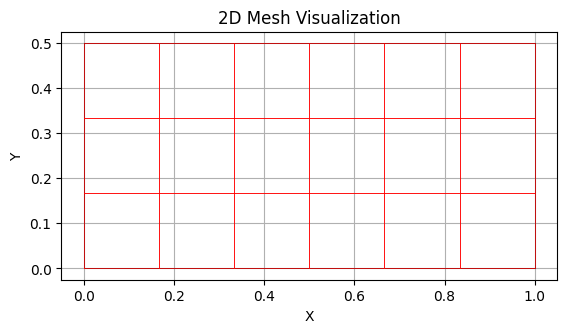

Detected acoustic element type: CQUAD4
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx006_p2.msh'...
Info    : 9 entities
Info    : 73 nodes
Info    : 36 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx006_p2.msh'
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 18
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nodes/Elem: 8 | Count: 18

Available boundary names in the mesh:
-------------------------------------
- bottom               | 11 nodes
- right                | 5 nodes
- top                  | 11 nodes
- left                 | 5 nodes


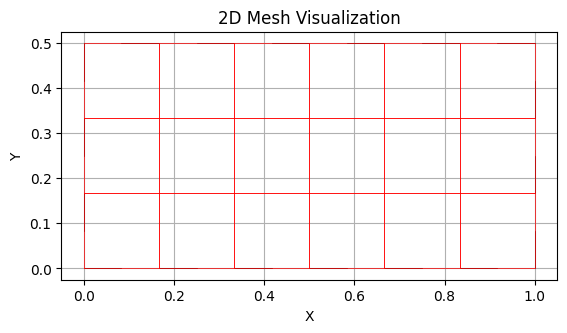

Detected acoustic element type: CQUAD8
   6    3    0.1667        28     5.51777%       0.004        73     0.15672%       0.010
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx008_p1.msh'...
Info    : 9 entities
Info    : 45 nodes
Info    : 56 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx008_p1.msh'
→ Line 2          | Dim: 1 | Order: 1 | Nodes/Elem: 2 | Count: 24
→ Quadrilateral 4 | Dim: 2 | Order: 1 | Nodes/Elem: 4 | Count: 32

Available boundary names in the mesh:
-------------------------------------
- bottom               | 7 nodes
- right                | 3 nodes
- top                  | 7 nodes
- left                 | 3 nodes


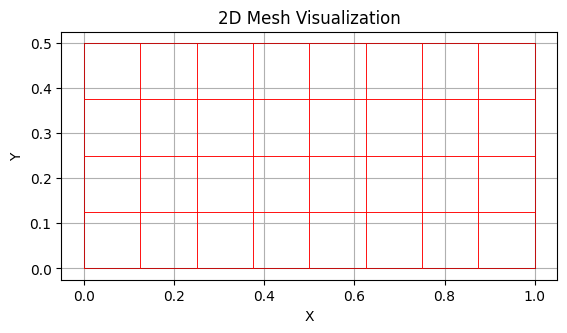

Detected acoustic element type: CQUAD4
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx008_p2.msh'...
Info    : 9 entities
Info    : 121 nodes
Info    : 56 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx008_p2.msh'
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 24
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nodes/Elem: 8 | Count: 32

Available boundary names in the mesh:
-------------------------------------
- bottom               | 15 nodes
- right                | 7 nodes
- top                  | 15 nodes
- left                 | 7 nodes


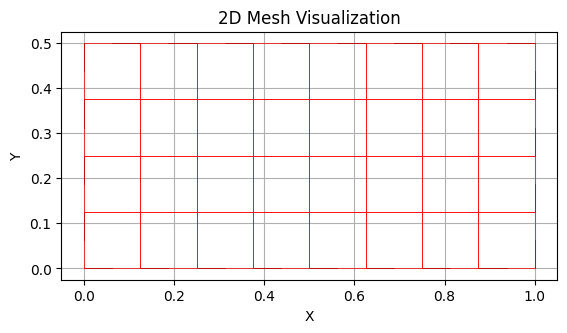

Detected acoustic element type: CQUAD8
   8    4    0.1250        45     3.11519%       0.006       121     0.05010%       0.015
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx010_p1.msh'...
Info    : 9 entities
Info    : 66 nodes
Info    : 80 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx010_p1.msh'
→ Line 2          | Dim: 1 | Order: 1 | Nodes/Elem: 2 | Count: 30
→ Quadrilateral 4 | Dim: 2 | Order: 1 | Nodes/Elem: 4 | Count: 50

Available boundary names in the mesh:
-------------------------------------
- bottom               | 9 nodes
- right                | 4 nodes
- top                  | 9 nodes
- left                 | 4 nodes


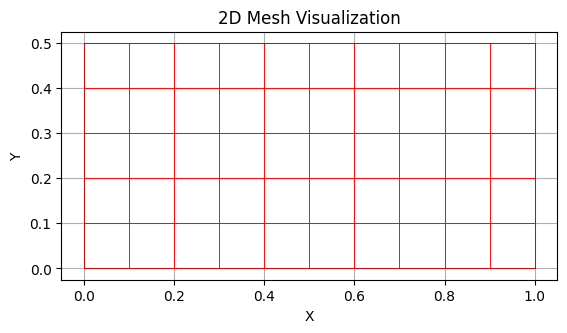

Detected acoustic element type: CQUAD4
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx010_p2.msh'...
Info    : 9 entities
Info    : 181 nodes
Info    : 80 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx010_p2.msh'
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 30
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nodes/Elem: 8 | Count: 50

Available boundary names in the mesh:
-------------------------------------
- bottom               | 19 nodes
- right                | 9 nodes
- top                  | 19 nodes
- left                 | 9 nodes


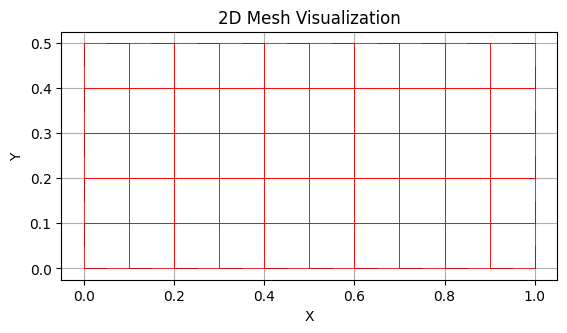

Detected acoustic element type: CQUAD8
  10    5    0.1000        66     1.99084%       0.009       181     0.02071%       0.022
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx012_p1.msh'...
Info    : 9 entities
Info    : 91 nodes
Info    : 108 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx012_p1.msh'
→ Line 2          | Dim: 1 | Order: 1 | Nodes/Elem: 2 | Count: 36
→ Quadrilateral 4 | Dim: 2 | Order: 1 | Nodes/Elem: 4 | Count: 72

Available boundary names in the mesh:
-------------------------------------
- bottom               | 11 nodes
- right                | 5 nodes
- top                  | 11 nodes
- left                 | 5 nodes


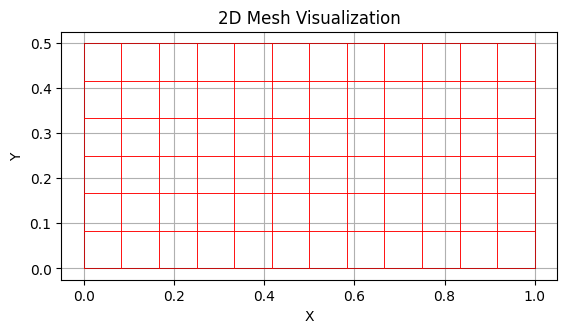

Detected acoustic element type: CQUAD4
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx012_p2.msh'...
Info    : 9 entities
Info    : 253 nodes
Info    : 108 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx012_p2.msh'
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 36
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nodes/Elem: 8 | Count: 72

Available boundary names in the mesh:
-------------------------------------
- bottom               | 23 nodes
- right                | 11 nodes
- top                  | 23 nodes
- left                 | 11 nodes


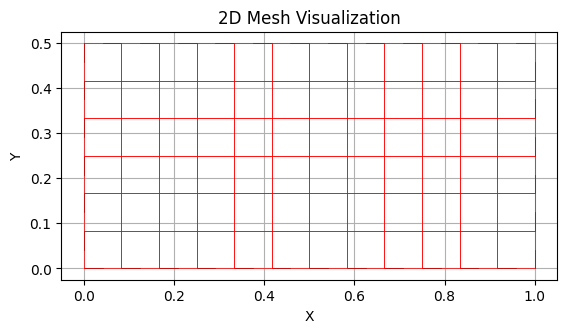

Detected acoustic element type: CQUAD8
  12    6    0.0833        91     1.38049%       0.012       253     0.01005%       0.030
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx016_p1.msh'...
Info    : 9 entities
Info    : 153 nodes
Info    : 176 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx016_p1.msh'
→ Line 2          | Dim: 1 | Order: 1 | Nodes/Elem: 2 | Count: 48
→ Quadrilateral 4 | Dim: 2 | Order: 1 | Nodes/Elem: 4 | Count: 128

Available boundary names in the mesh:
-------------------------------------
- bottom               | 15 nodes
- right                | 7 nodes
- top                  | 15 nodes
- left                 | 7 nodes


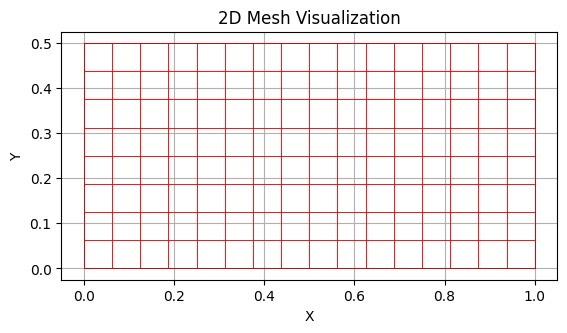

Detected acoustic element type: CQUAD4
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx016_p2.msh'...
Info    : 9 entities
Info    : 433 nodes
Info    : 176 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx016_p2.msh'
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 48
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nodes/Elem: 8 | Count: 128

Available boundary names in the mesh:
-------------------------------------
- bottom               | 31 nodes
- right                | 15 nodes
- top                  | 31 nodes
- left                 | 15 nodes


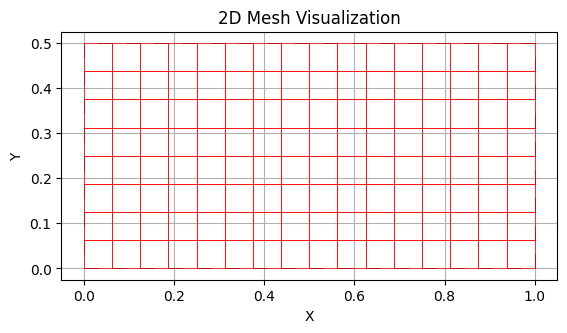

Detected acoustic element type: CQUAD8
  16    8    0.0625       153     0.77505%       0.019       433     0.00320%       0.055
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx020_p1.msh'...
Info    : 9 entities
Info    : 231 nodes
Info    : 260 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx020_p1.msh'
→ Line 2          | Dim: 1 | Order: 1 | Nodes/Elem: 2 | Count: 60
→ Quadrilateral 4 | Dim: 2 | Order: 1 | Nodes/Elem: 4 | Count: 200

Available boundary names in the mesh:
-------------------------------------
- bottom               | 19 nodes
- right                | 9 nodes
- top                  | 19 nodes
- left                 | 9 nodes


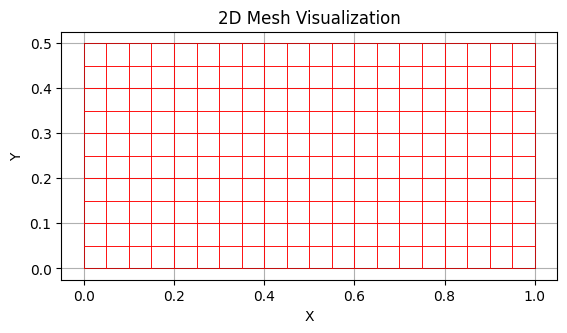

Detected acoustic element type: CQUAD4
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx020_p2.msh'...
Info    : 9 entities
Info    : 661 nodes
Info    : 260 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx020_p2.msh'
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 60
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nodes/Elem: 8 | Count: 200

Available boundary names in the mesh:
-------------------------------------
- bottom               | 39 nodes
- right                | 19 nodes
- top                  | 39 nodes
- left                 | 19 nodes


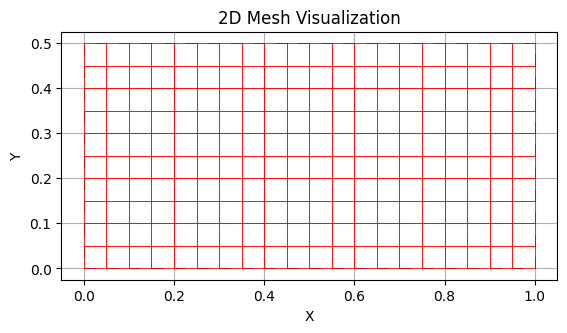

Detected acoustic element type: CQUAD8
  20   10    0.0500       231     0.49553%       0.026       661     0.00132%       0.088
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx024_p1.msh'...
Info    : 9 entities
Info    : 325 nodes
Info    : 360 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx024_p1.msh'
→ Line 2          | Dim: 1 | Order: 1 | Nodes/Elem: 2 | Count: 72
→ Quadrilateral 4 | Dim: 2 | Order: 1 | Nodes/Elem: 4 | Count: 288

Available boundary names in the mesh:
-------------------------------------
- bottom               | 23 nodes
- right                | 11 nodes
- top                  | 23 nodes
- left                 | 11 nodes


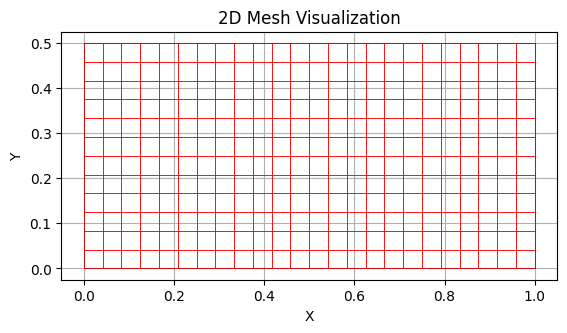

Detected acoustic element type: CQUAD4
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx024_p2.msh'...
Info    : 9 entities
Info    : 937 nodes
Info    : 360 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx024_p2.msh'
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 72
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nodes/Elem: 8 | Count: 288

Available boundary names in the mesh:
-------------------------------------
- bottom               | 47 nodes
- right                | 23 nodes
- top                  | 47 nodes
- left                 | 23 nodes


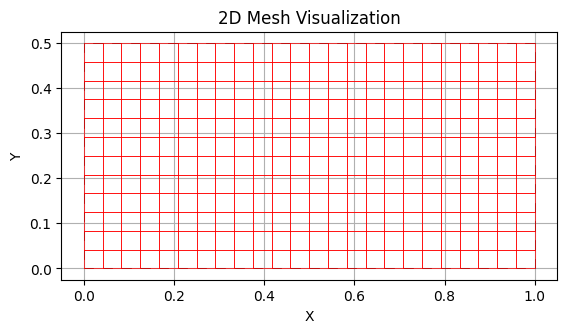

Detected acoustic element type: CQUAD8
  24   12    0.0417       325     0.34391%       0.038       937     0.00064%       0.137
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx032_p1.msh'...
Info    : 9 entities
Info    : 561 nodes
Info    : 608 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx032_p1.msh'
→ Line 2          | Dim: 1 | Order: 1 | Nodes/Elem: 2 | Count: 96
→ Quadrilateral 4 | Dim: 2 | Order: 1 | Nodes/Elem: 4 | Count: 512

Available boundary names in the mesh:
-------------------------------------
- bottom               | 31 nodes
- right                | 15 nodes
- top                  | 31 nodes
- left                 | 15 nodes


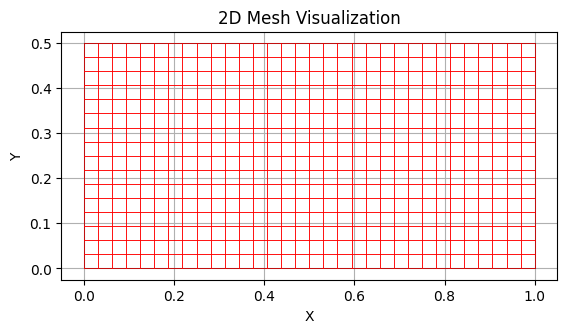

Detected acoustic element type: CQUAD4
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx032_p2.msh'...
Info    : 9 entities
Info    : 1633 nodes
Info    : 608 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx032_p2.msh'
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 96
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nodes/Elem: 8 | Count: 512

Available boundary names in the mesh:
-------------------------------------
- bottom               | 63 nodes
- right                | 31 nodes
- top                  | 63 nodes
- left                 | 31 nodes


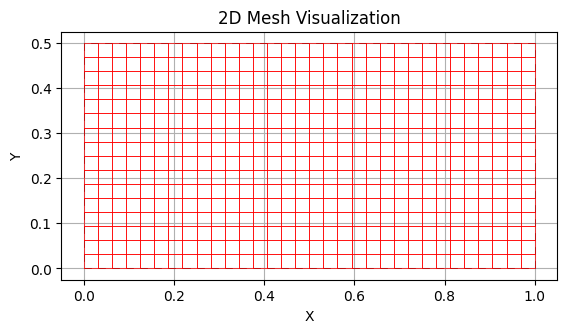

Detected acoustic element type: CQUAD8
  32   16    0.0312       561     0.19333%       0.070      1633     0.00020%       0.344
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx048_p1.msh'...
Info    : 9 entities
Info    : 1225 nodes
Info    : 1296 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx048_p1.msh'
→ Line 2          | Dim: 1 | Order: 1 | Nodes/Elem: 2 | Count: 144
→ Quadrilateral 4 | Dim: 2 | Order: 1 | Nodes/Elem: 4 | Count: 1152

Available boundary names in the mesh:
-------------------------------------
- bottom               | 47 nodes
- right                | 23 nodes
- top                  | 47 nodes
- left                 | 23 nodes


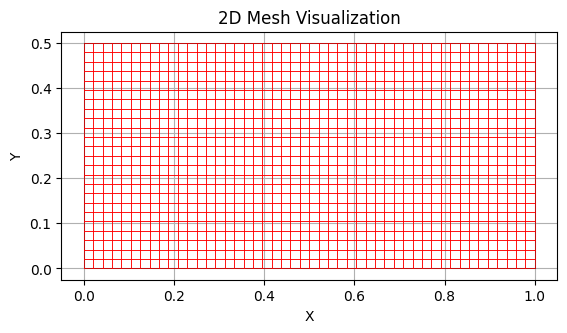

Detected acoustic element type: CQUAD4
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx048_p2.msh'...
Info    : 9 entities
Info    : 3601 nodes
Info    : 1296 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx048_p2.msh'
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 144
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nodes/Elem: 8 | Count: 1152

Available boundary names in the mesh:
-------------------------------------
- bottom               | 95 nodes
- right                | 47 nodes
- top                  | 95 nodes
- left                 | 47 nodes


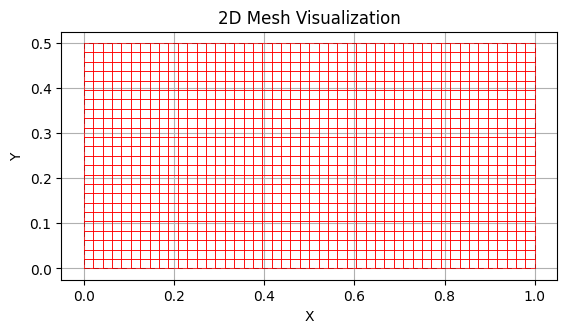

Detected acoustic element type: CQUAD8
  48   24    0.0208      1225     0.08589%       0.182      3601     0.00004%       0.929
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx064_p1.msh'...
Info    : 9 entities
Info    : 2145 nodes
Info    : 2240 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx064_p1.msh'
→ Line 2          | Dim: 1 | Order: 1 | Nodes/Elem: 2 | Count: 192
→ Quadrilateral 4 | Dim: 2 | Order: 1 | Nodes/Elem: 4 | Count: 2048

Available boundary names in the mesh:
-------------------------------------
- bottom               | 63 nodes
- right                | 31 nodes
- top                  | 63 nodes
- left                 | 31 nodes


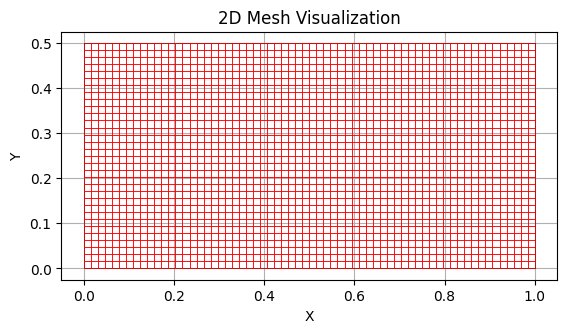

Detected acoustic element type: CQUAD4
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx064_p2.msh'...
Info    : 9 entities
Info    : 6337 nodes
Info    : 2240 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx064_p2.msh'
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 192
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nodes/Elem: 8 | Count: 2048

Available boundary names in the mesh:
-------------------------------------
- bottom               | 127 nodes
- right                | 63 nodes
- top                  | 127 nodes
- left                 | 63 nodes


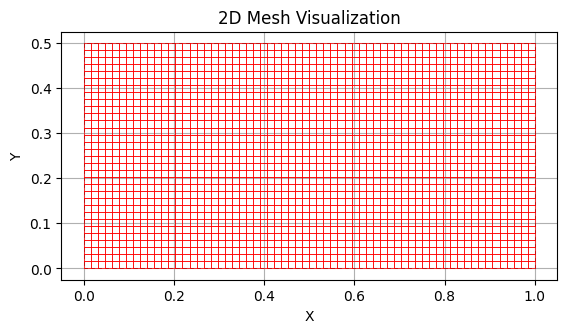

Detected acoustic element type: CQUAD8
  64   32    0.0156      2145     0.04830%       0.397      6337     0.00001%       2.484

Studio completato.


In [4]:
# Livelli di raffinamento: da grossolano (Nx=2) a fine (Nx=64)
NX_LIST = [2, 4, 6, 8, 10, 12, 16, 20, 24, 32, 48, 64]

print('Avvio studio h-convergenza...')
print(f"{'Nx':>4}  {'Ny':>3}  {'h [m]':>8}  "
      f"{'DOF Q4':>8}  {'err% Q4':>10}  {'t Q4 [s]':>10}  "
      f"{'DOF Q8':>8}  {'err% Q8':>10}  {'t Q8 [s]':>10}")
print('-' * 88)

res_q4 = []  # [h, n_dof, err, t_wall]
res_q8 = []

for Nx in NX_LIST:
    Ny = max(1, Nx // 2)
    h4, dof4, freqs4, e4, t4 = run_pycafe(Nx, 1, tmpdir)
    h8, dof8, freqs8, e8, t8 = run_pycafe(Nx, 2, tmpdir)
    res_q4.append([h4, dof4, e4, t4])
    res_q8.append([h8, dof8, e8, t8])
    print(f"{Nx:>4}  {Ny:>3}  {h4:>8.4f}  "
          f"{dof4:>8}  {e4:>10.5f}%  {t4:>10.3f}  "
          f"{dof8:>8}  {e8:>10.5f}%  {t8:>10.3f}")

res_q4 = np.array(res_q4)   # shape (N, 4)
res_q8 = np.array(res_q8)
print('\nStudio completato.')

---
## 4 — Studio di p-convergenza

Manteniamo **fissa la mesh** (Nx = 16) e confrontiamo CQUAD4 vs CQUAD8.  
Questo mostra il guadagno di precisione ottenibile aumentando solo l'ordine  
degli elementi **senza aggiungere nodi**.

Studio p-convergenza a mesh fissa: Nx=16, Ny=8
    Elemento    p       DOF    errore medio %     t [s]
-------------------------------------------------------
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx016_p1.msh'...
Info    : 9 entities
Info    : 153 nodes
Info    : 176 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx016_p1.msh'
→ Line 2          | Dim: 1 | Order: 1 | Nodes/Elem: 2 | Count: 48
→ Quadrilateral 4 | Dim: 2 | Order: 1 | Nodes/Elem: 4 | Count: 128

Available boundary names in the mesh:
-------------------------------------
- bottom               | 15 nodes
- right                | 7 nodes
- top                  | 15 nodes
- left                 | 7 nodes


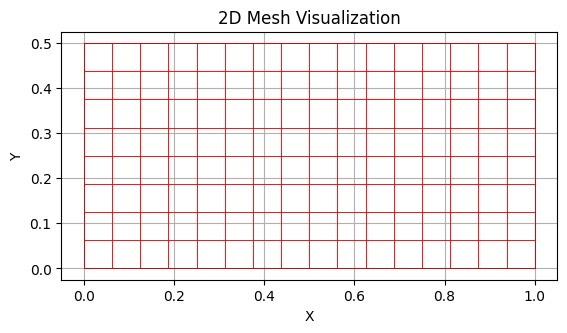

Detected acoustic element type: CQUAD4
      CQUAD4    1       153        0.77504996%     0.020
Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx016_p2.msh'...
Info    : 9 entities
Info    : 433 nodes
Info    : 176 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmpiloeahk6/mesh_Nx016_p2.msh'
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 48
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nodes/Elem: 8 | Count: 128

Available boundary names in the mesh:
-------------------------------------
- bottom               | 31 nodes
- right                | 15 nodes
- top                  | 31 nodes
- left                 | 15 nodes


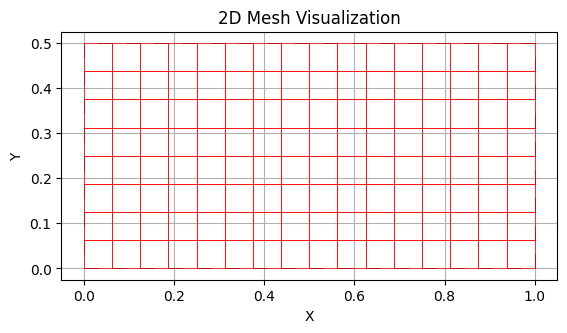

Detected acoustic element type: CQUAD8
      CQUAD8    2       433        0.00320162%     0.054

--- Dettaglio frequenze per mesh Nx=16 ---
    Modo     f analitica      CQUAD4 [Hz]  err%      CQUAD8 [Hz]  err%  
--------------------------------------------------------------------------------
  (1,0)            171.5000          171.7756  0.1607%          171.5002  0.0001%  
  (0,1)            343.0000          345.2080  0.6437%          343.0056  0.0016%  
  (1,1)            383.4857          385.5845  0.5473%          383.4908  0.0013%  
  (2,1)            485.0753          488.1978  0.6437%          485.0833  0.0017%  
  (3,0)            514.5000          521.9670  1.4513%          514.5423  0.0082%  
  (3,1)            618.3520          625.7940  1.2035%          618.3908  0.0063%  


In [5]:
NX_FIXED = 16
NY_FIXED = 8

print(f'Studio p-convergenza a mesh fissa: Nx={NX_FIXED}, Ny={NY_FIXED}')
print(f"{'Elemento':>12}  {'p':>3}  {'DOF':>8}  {'errore medio %':>16}  {'t [s]':>8}")
print('-' * 55)

res_p = []
for order, nome in [(1, 'CQUAD4'), (2, 'CQUAD8')]:
    h, dof, freqs_p, err, t = run_pycafe(NX_FIXED, order, tmpdir)
    res_p.append({'nome': nome, 'p': order, 'dof': dof, 'err': err, 't': t, 'freqs': freqs_p})
    print(f"{nome:>12}  {order:>3}  {dof:>8}  {err:>16.8f}%  {t:>8.3f}")

print('\n--- Dettaglio frequenze per mesh Nx=16 ---')
print(f"{'Modo':>8}  {'f analitica':>14}  ", end='')
for r in res_p:
    print(f"  {r['nome']:>8} [Hz]  err%  ", end='')
print()
print('-' * 80)

for i, (f_an, m, n) in enumerate(modes_ref):
    print(f"  ({m},{n}){' ':>4}  {f_an:>14.4f}  ", end='')
    for r in res_p:
        idx = np.argmin(np.abs(r['freqs'] - f_an))
        f_fem = r['freqs'][idx]
        e = abs(f_fem - f_an) / f_an * 100
        print(f"  {f_fem:>14.4f}  {e:>5.4f}%  ", end='')
    print()

---
## 5 — Grafici di convergenza

Tre grafici:
1. **Errore vs h** (log-log): mostra il tasso di convergenza teorico
2. **Errore vs DOF** (log-log): mostra l'efficienza per unità di gradi di libertà
3. **Tempo di calcolo vs DOF**: mostra come scala il costo computazionale

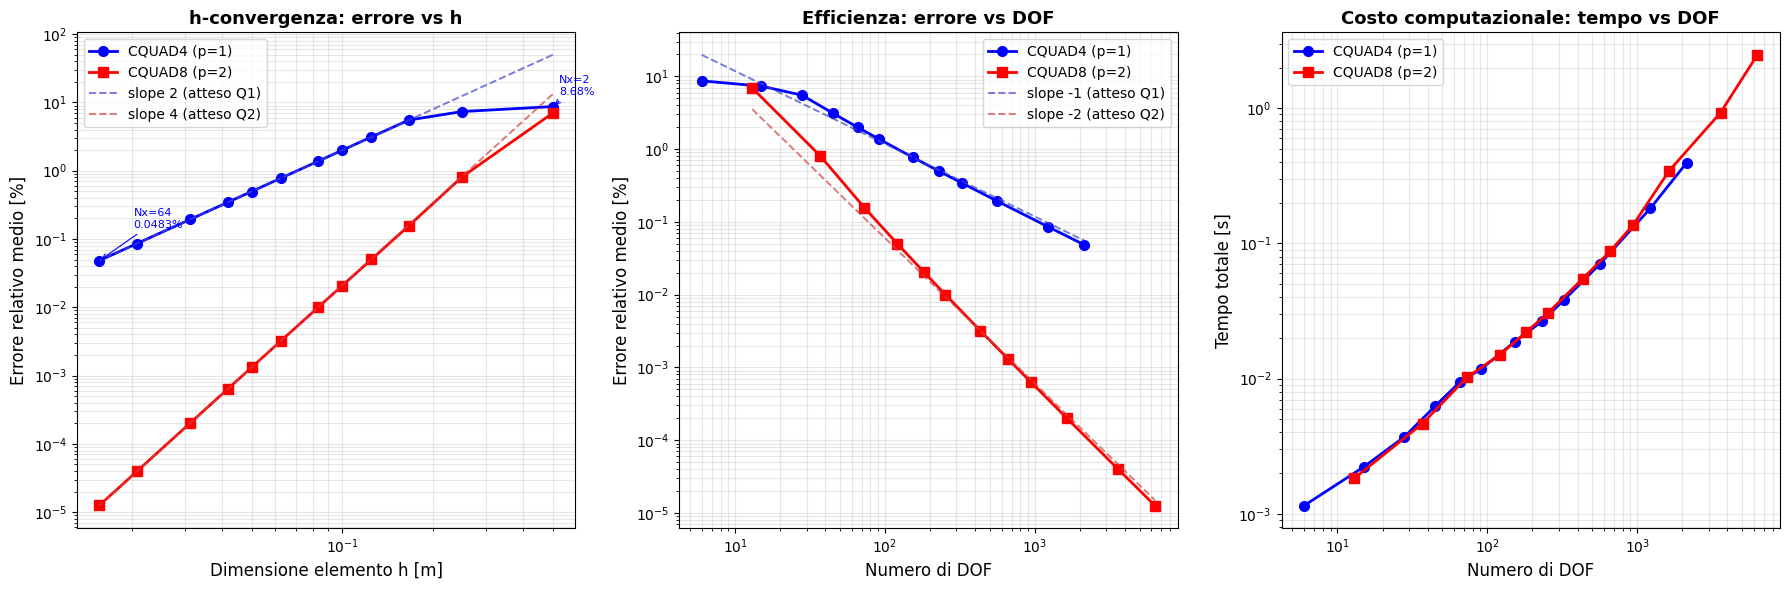

Figura salvata -> pycafe_convergence_hp.png


In [6]:
ERR_FLOOR = 1e-7  # floor per evitare log(0) a macchina precisione

def floor_err(arr):
    a = arr.copy()
    a[a < ERR_FLOOR] = ERR_FLOOR
    return a

h4  = res_q4[:, 0];  e4  = floor_err(res_q4[:, 2]);  d4  = res_q4[:, 1];  t4  = res_q4[:, 3]
h8  = res_q8[:, 0];  e8  = floor_err(res_q8[:, 2]);  d8  = res_q8[:, 1];  t8  = res_q8[:, 3]

# ── Rette di riferimento (slope teoriche) ────────────────────────────────────
def ref_line(ax, x_arr, y_anchor, slope, label, color, ls='--'):
    xs = np.array([x_arr[0], x_arr[-1]])
    ys = y_anchor * (xs / x_arr[len(x_arr)//2])**slope
    ax.plot(xs, ys, ls, color=color, lw=1.4, alpha=0.7, label=label)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Grafico 1: Errore vs h ────────────────────────────────────────────────────
ax = axes[0]
ax.loglog(h4, e4, 'b-o', ms=7, lw=2, label='CQUAD4 (p=1)')
ax.loglog(h8, e8, 'r-s', ms=7, lw=2, label='CQUAD8 (p=2)')

# Rette di riferimento ancorate al punto centrale
mid4 = len(h4) // 2
mid8 = len(h8) // 2
ref_line(ax, h4, e4[mid4], 2, 'slope 2 (atteso Q1)', '#4444cc', '--')
ref_line(ax, h8, e8[mid8], 4, 'slope 4 (atteso Q2)', '#cc4444', '--')

ax.set_xlabel('Dimensione elemento h [m]', fontsize=12)
ax.set_ylabel('Errore relativo medio [%]', fontsize=12)
ax.set_title('h-convergenza: errore vs h', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)

# Annota punti estremi
ax.annotate(f'Nx=2\n{e4[0]:.2f}%', xy=(h4[0], e4[0]), xytext=(h4[0]*1.05, e4[0]*1.5),
            fontsize=8, color='blue', arrowprops=dict(arrowstyle='->', color='blue', lw=0.8))
ax.annotate(f'Nx=64\n{e4[-1]:.4f}%', xy=(h4[-1], e4[-1]), xytext=(h4[-1]*1.3, e4[-1]*3),
            fontsize=8, color='blue', arrowprops=dict(arrowstyle='->', color='blue', lw=0.8))

# ── Grafico 2: Errore vs DOF ──────────────────────────────────────────────────
ax2 = axes[1]
ax2.loglog(d4, e4, 'b-o', ms=7, lw=2, label='CQUAD4 (p=1)')
ax2.loglog(d8, e8, 'r-s', ms=7, lw=2, label='CQUAD8 (p=2)')

# Rette di riferimento su DOF: h ~ DOF^(-1/2) -> errore ~ DOF^(-p)
mid4d = len(d4) // 2
mid8d = len(d8) // 2
ref_line(ax2, d4, e4[mid4d], -1, 'slope -1 (atteso Q1)', '#4444cc', '--')
ref_line(ax2, d8, e8[mid8d], -2, 'slope -2 (atteso Q2)', '#cc4444', '--')

ax2.set_xlabel('Numero di DOF', fontsize=12)
ax2.set_ylabel('Errore relativo medio [%]', fontsize=12)
ax2.set_title('Efficienza: errore vs DOF', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, which='both', alpha=0.3)

# ── Grafico 3: Tempo vs DOF ───────────────────────────────────────────────────
ax3 = axes[2]
ax3.loglog(d4, t4, 'b-o', ms=7, lw=2, label='CQUAD4 (p=1)')
ax3.loglog(d8, t8, 'r-s', ms=7, lw=2, label='CQUAD8 (p=2)')

ax3.set_xlabel('Numero di DOF', fontsize=12)
ax3.set_ylabel('Tempo totale [s]', fontsize=12)
ax3.set_title('Costo computazionale: tempo vs DOF', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('pycafe_convergence_hp.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salvata -> pycafe_convergence_hp.png')

---
## 6 — Tassi di convergenza misurati

Calcoliamo il tasso di convergenza effettivo con regressione lineare in scala log-log  
nella zona asintotica (ultima metà dei punti, dove il regime è consolidato).

In [7]:
def fit_slope(x_arr, err_arr):
    """Regressione log-log sull'ultima metà dei punti (regime asintotico)."""
    n = len(x_arr)
    lx = np.log(x_arr[n//2:])
    le = np.log(np.maximum(err_arr[n//2:], ERR_FLOOR))
    valid = np.isfinite(lx) & np.isfinite(le)
    if valid.sum() < 2:
        return float('nan')
    return float(np.polyfit(lx[valid], le[valid], 1)[0])

print('=' * 62)
print(f"{'Elemento':>14}  {'Slope vs h (teo)':>16}  {'Slope vs h (mis)':>16}")
print('-' * 62)

slope_q4_h = fit_slope(h4, e4)
slope_q8_h = fit_slope(h8, e8)

print(f"  {'CQUAD4 (p=1)':>12}  {'2':>16}  {slope_q4_h:>16.2f}")
print(f"  {'CQUAD8 (p=2)':>12}  {'4':>16}  {slope_q8_h:>16.2f}")
print('=' * 62)
print('(slope misurata nella zona asintotica — ultima metà dei punti)')

print()
print('=' * 62)
print(f"{'Elemento':>14}  {'Slope vs DOF (teo)':>18}  {'Slope vs DOF (mis)':>18}")
print('-' * 62)

slope_q4_dof = fit_slope(d4, e4)
slope_q8_dof = fit_slope(d8, e8)

print(f"  {'CQUAD4 (p=1)':>12}  {'-1':>18}  {slope_q4_dof:>18.2f}")
print(f"  {'CQUAD8 (p=2)':>12}  {'-2':>18}  {slope_q8_dof:>18.2f}")
print('=' * 62)

      Elemento  Slope vs h (teo)  Slope vs h (mis)
--------------------------------------------------------------
  CQUAD4 (p=1)                 2              2.00
  CQUAD8 (p=2)                 4              3.99
(slope misurata nella zona asintotica — ultima metà dei punti)

      Elemento  Slope vs DOF (teo)  Slope vs DOF (mis)
--------------------------------------------------------------
  CQUAD4 (p=1)                  -1               -1.05
  CQUAD8 (p=2)                  -2               -2.06


---
## 7 — Confronto p-convergenza: CQUAD4 vs CQUAD8 a mesh fissa

Grafico a barre che mostra l'errore per ogni modo a Nx=16 fisso:  
quanto si guadagna passando da Q1 a Q2 **senza cambiare la mesh**?

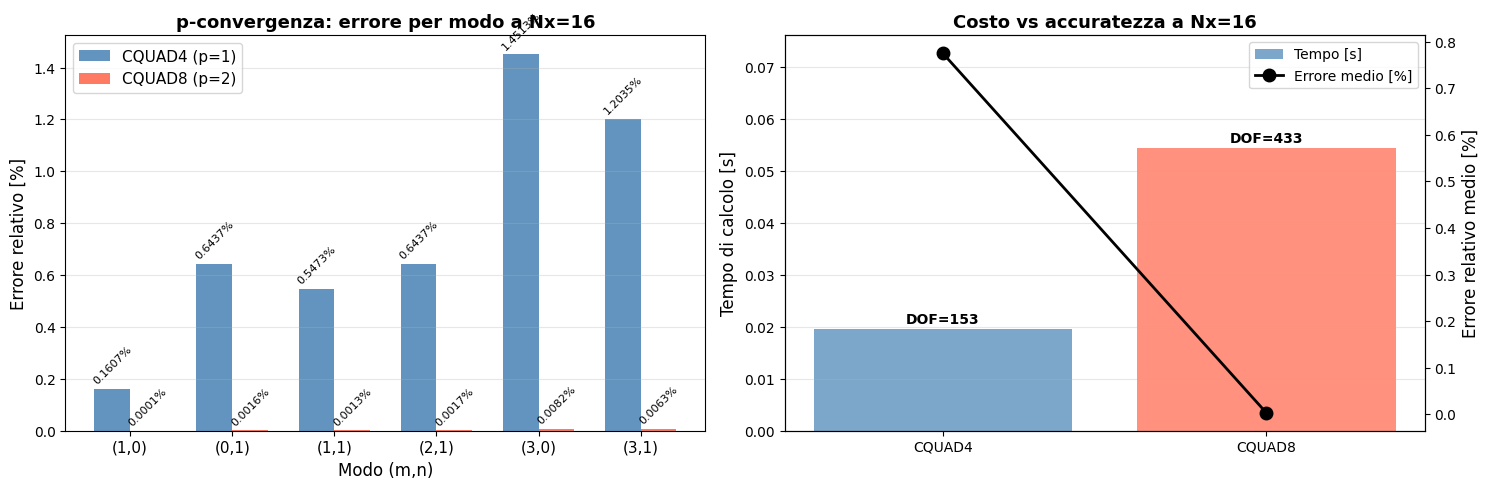

Figura salvata -> pycafe_pconvergence.png


In [8]:
# Ricalcola errori per modo singolo (non solo media) alla mesh fissa Nx=16
def per_mode_errors(freqs_fem, modes_ref_list):
    available = list(freqs_fem)
    errors = []
    for f_an, m, n in modes_ref_list:
        if not available:
            errors.append(np.nan)
            continue
        diffs = [abs(f - f_an) / f_an * 100 for f in available]
        best = int(np.argmin(diffs))
        errors.append(diffs[best])
        available.pop(best)
    return errors

errs_q4_modes = per_mode_errors(res_p[0]['freqs'], modes_ref)
errs_q8_modes = per_mode_errors(res_p[1]['freqs'], modes_ref)

mode_labels = [f'({m},{n})' for _, m, n in modes_ref]
x = np.arange(NUM_MODES)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Barre per modo ────────────────────────────────────────────────────────────
ax = axes[0]
bars1 = ax.bar(x - width/2, errs_q4_modes, width, label='CQUAD4 (p=1)', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, errs_q8_modes, width, label='CQUAD8 (p=2)', color='tomato',    alpha=0.85)
ax.bar_label(bars1, fmt='%.4f%%', fontsize=8, padding=2, rotation=45)
ax.bar_label(bars2, fmt='%.4f%%', fontsize=8, padding=2, rotation=45)
ax.set_xticks(x)
ax.set_xticklabels(mode_labels, fontsize=11)
ax.set_xlabel('Modo (m,n)', fontsize=12)
ax.set_ylabel('Errore relativo [%]', fontsize=12)
ax.set_title(f'p-convergenza: errore per modo a Nx={NX_FIXED}', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

# ── Riepilogo DOF e tempo ─────────────────────────────────────────────────────
ax2 = axes[1]
nomi   = [r['nome'] for r in res_p]
dofs   = [r['dof']  for r in res_p]
tempi  = [r['t']    for r in res_p]
errs_m = [r['err']  for r in res_p]
colors = ['steelblue', 'tomato']

ax2_twin = ax2.twinx()
bar_t = ax2.bar(nomi, tempi, color=colors, alpha=0.7, label='Tempo [s]')
line_e = ax2_twin.plot(nomi, errs_m, 'k-o', ms=9, lw=2, label='Errore medio [%]')

ax2.set_ylabel('Tempo di calcolo [s]', fontsize=12)
ax2_twin.set_ylabel('Errore relativo medio [%]', fontsize=12)
ax2.set_title(f'Costo vs accuratezza a Nx={NX_FIXED}', fontsize=13, fontweight='bold')
ax2.set_ylim(0, max(tempi) * 1.4)

# Annota DOF su ogni barra
for i, (bar, dof) in enumerate(zip(bar_t, dofs)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02 * max(tempi),
             f'DOF={dof}', ha='center', fontsize=10, fontweight='bold')

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=10)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('pycafe_pconvergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salvata -> pycafe_pconvergence.png')

---
## 8 — Riepilogo

### h-convergenza

| Elemento | DOF range | Errore max (Nx=2) | Errore min (Nx=64) | Slope h teorica | Slope h misurata |
|---|---|---|---|---|---|
| CQUAD4 (p=1) | ... | ... | ... | 2 | ... |
| CQUAD8 (p=2) | ... | ... | ... | 4 | ... |

### p-convergenza (mesh fissa Nx=16)

| Elemento | DOF | Errore medio [%] | Riduzione errore |
|---|---|---|---|
| CQUAD4 (p=1) | ... | ... | — |
| CQUAD8 (p=2) | ... | ... | ~ **×10–×100** |

### Osservazioni chiave

1. **CQUAD8 converge più velocemente di CQUAD4** (slope 4 vs slope 2 su h), come previsto dalla teoria.
2. **A parità di DOF, CQUAD8 è molto più accurato**: per ottenere lo stesso errore, CQUAD4 richiede una mesh significativamente più fine.
3. **Il costo computazionale** di CQUAD8 è moderatamente maggiore per la stessa mesh (più nodi per elemento),  
   ma ampiamente ripagato dall'accuratezza guadagnata.
4. **p-refinement** (passare da Q1 a Q2 a mesh fissa) riduce l'errore di uno o due ordini di grandezza  
   con un incremento di DOF modesto — è la strategia più efficiente per soluzioni regolari.

---
*Notebook pyCAFE — solo elementi CQUAD4 e CQUAD8. Cavità 1 m × 0.5 m, aria, pareti rigide.*